In [47]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

**Imports**

In [48]:
import os
import pandas as pd
import numpy as np

**Load Data**

In [49]:
path = "/content/data/data/"

dataframes = {}

for file in os.listdir(path):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        df = pd.read_csv(path + file, on_bad_lines='skip')
        dataframes[name] = df

print(dataframes.keys())

dict_keys(['imaging_studies', 'allergies', 'immunizations', 'organizations', 'payer_transitions', 'claims', 'careplans', 'patients', 'procedures', 'conditions', 'observations', 'encounters', 'devices', 'supplies', 'medications', 'claims_transactions', 'providers'])


**Select Tables**

In [50]:
patients = dataframes["patients"]
observations = dataframes["observations"]
conditions = dataframes["conditions"]

print(patients.head())
print(observations.head())
print(conditions.head())

                                     Id   BIRTHDATE   DEATHDATE          SSN  \
0  0f238ca9-106f-4cd6-d8d1-701e70c84cb6  2001-01-10  2001-09-21  999-65-9711   
1  a35facb9-a2fd-363c-dc7f-5f32ed850c45  1971-03-31  1983-06-17  999-17-4477   
2  e3e20559-00f1-a5b1-0e26-4145235cccbf  2016-09-06         NaN  999-24-6886   
3  90f0bc22-78e9-3b0c-0479-e2d5091cba18  2003-09-18         NaN  999-23-7519   
4  f9b654e0-f9bd-b806-5e72-fbe4a7463c94  2006-08-10         NaN  999-77-6032   

     DRIVERS    PASSPORT PREFIX         FIRST      MIDDLE        LAST  ...  \
0        NaN         NaN    NaN   Eldridge510         NaN   Murphy561  ...   
1        NaN         NaN    NaN  Fransisca150         NaN  Tillman293  ...   
2        NaN         NaN    NaN     Indira327  Stefany238     Moen819  ...   
3  S99954943  X74471475X    Mr.     Carmen818         NaN  Hilpert278  ...   
4  S99954224         NaN    Mr.     Kelley882         NaN     Lind531  ...   

          CITY          STATE            COUNTY   

**Fix VALUE column**

In [51]:
print("PATIENTS:", patients.columns)
print("OBSERVATIONS:", observations.columns)
print("CONDITIONS:", conditions.columns)

PATIENTS: Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')
OBSERVATIONS: Index(['DATE', 'PATIENT', 'ENCOUNTER', 'CATEGORY', 'CODE', 'DESCRIPTION',
       'VALUE', 'UNITS', 'TYPE'],
      dtype='object')
CONDITIONS: Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE',
       'DESCRIPTION', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='object')


**Aggregate Observations**

In [52]:
conditions["target"] = conditions["DESCRIPTION"].astype(str).str.lower().apply(
    lambda x: 1 if "diabetes" in x else 0
)

target_df = conditions[["PATIENT", "target"]].drop_duplicates()

**Create Target**

In [53]:
observations["VALUE"] = pd.to_numeric(observations["VALUE"], errors="coerce")
observations = observations.dropna(subset=["VALUE"])

print("VALUE cleaned")

VALUE cleaned


**Merge Dataset**

In [54]:
obs_agg = observations.groupby("PATIENT").agg({
    "VALUE": ["mean", "std"]
}).reset_index()

obs_agg.columns = ["PATIENT", "obs_mean", "obs_std"]

print(obs_agg.head())

                                PATIENT     obs_mean       obs_std
0  00043074-bbc9-7d65-195e-e615d7b61dcb  3822.619289  21303.316328
1  0033b4c0-255c-af66-8fc9-ebe17f725461  9044.025210  43143.556204
2  0050e373-575d-88b8-f682-64abf43ae57e    52.763006     65.657324
3  0054eccc-84f7-ff56-75cf-d4dc86f63a7a    46.263953     49.757146
4  00a56f5f-4707-007f-9132-bf26fd1ceee8   147.403794   1524.915644


**Time Split**

In [55]:
conditions["target"] = conditions["DESCRIPTION"].astype(str).str.lower().apply(
    lambda x: 1 if "diabetes" in x else 0
)

target_df = conditions[["PATIENT", "target"]].drop_duplicates()

print(target_df.head())

                                 PATIENT  target
0   0f238ca9-106f-4cd6-d8d1-701e70c84cb6       0
6   a35facb9-a2fd-363c-dc7f-5f32ed850c45       0
17  e3e20559-00f1-a5b1-0e26-4145235cccbf       0
38  90f0bc22-78e9-3b0c-0479-e2d5091cba18       0
59  f9b654e0-f9bd-b806-5e72-fbe4a7463c94       0


**Clean + Encode**

In [71]:
df = df.fillna(df.mean(numeric_only=True))

df = pd.get_dummies(df)

df = df.select_dtypes(include=[np.number])

print("Cleaned full df:", df.shape)

Cleaned full df: (151, 10)


**Align Columns**

In [57]:
df["timestamp"] = pd.to_datetime(df["BIRTHDATE"])
df = df.sort_values("timestamp")

split_index = int(len(df) * 0.7)

df1 = df.iloc[:split_index]
df2 = df.iloc[split_index:]

print("Split done")

Split done


**Train/Test Split**

In [73]:
from sklearn.model_selection import train_test_split

X1 = df1.drop("target", axis=1)
y1 = df1["target"]

X2 = df2.drop("target", axis=1)
y2 = df2["target"]

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

X_train_2 = X_train_2.reindex(columns=X_train_1.columns, fill_value=0)
X_test_2 = X_test_2.reindex(columns=X_train_1.columns, fill_value=0)

**Scaling**

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_1 = scaler.fit_transform(X_train_1)
X_test_1 = scaler.transform(X_test_1)

X_train_2 = scaler.transform(X_train_2[X1.columns])
X_test_2 = scaler.transform(X_test_2[X1.columns])

**Train Models**

In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

dt = DecisionTreeClassifier(max_depth=5)
svm = SVC(probability=True)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)

dt.fit(X_train_1, y_train_1)
svm.fit(X_train_1, y_train_1)
mlp.fit(X_train_1, y_train_1)

print("Models trained")

Models trained


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


**Evaluation Function**

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds),
        "recall": recall_score(y, preds),
        "f1": f1_score(y, preds),
        "roc": roc_auc_score(y, probs)
    }

**Evaluate on BOTH datasets**

In [81]:
results = {}

# Decision Tree
results["DT_D1"] = evaluate(dt, X_test_1, y_test_1)
results["DT_D2"] = evaluate(dt, X_test_2, y_test_2)

# SVM
results["SVM_D1"] = evaluate(svm, X_test_1, y_test_1)
results["SVM_D2"] = evaluate(svm, X_test_2, y_test_2)

# MLP
results["MLP_D1"] = evaluate(mlp, X_test_1, y_test_1)
results["MLP_D2"] = evaluate(mlp, X_test_2, y_test_2)

print(results)

{'DT_D1': {'accuracy': 0.5714285714285714, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.2777777777777778)}, 'DT_D2': {'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}, 'SVM_D1': {'accuracy': 0.6190476190476191, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.7722222222222223)}, 'SVM_D2': {'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}, 'MLP_D1': {'accuracy': 0.3333333333333333, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.12222222222222222)}, 'MLP_D2': {'accuracy': 0.6, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: U

**Continual Learning**

In [82]:
mlp.fit(X_train_2, y_train_2)

results["MLP_after_CL"] = evaluate(mlp, X_test_2, y_test_2)

print(results)

{'DT_D1': {'accuracy': 0.5714285714285714, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.2777777777777778)}, 'DT_D2': {'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}, 'SVM_D1': {'accuracy': 0.6190476190476191, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.7722222222222223)}, 'SVM_D2': {'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}, 'MLP_D1': {'accuracy': 0.3333333333333333, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': np.float64(0.12222222222222222)}, 'MLP_D2': {'accuracy': 0.6, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}, 'MLP_after_CL': {'accuracy': 0.9, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc': nan}}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


**Save Models + Metrics**

In [83]:
import joblib
import pandas as pd

joblib.dump(dt, "dt.pkl")
joblib.dump(svm, "svm.pkl")
joblib.dump(mlp, "mlp.pkl")

df_results = pd.DataFrame(results).T
df_results.to_csv("metrics.csv")

df_results

,accuracy,precision,recall,f1,roc
DT_D1,0.571429,0.0,0.0,0.0,0.277778
DT_D2,1.000000,0.0,0.0,0.0,NaN
SVM_D1,0.619048,0.0,0.0,0.0,0.772222
SVM_D2,1.000000,0.0,0.0,0.0,NaN
MLP_D1,0.333333,0.0,0.0,0.0,0.122222
MLP_D2,0.600000,0.0,0.0,0.0,NaN
MLP_after_CL,0.900000,0.0,0.0,0.0,NaN


**Plot**

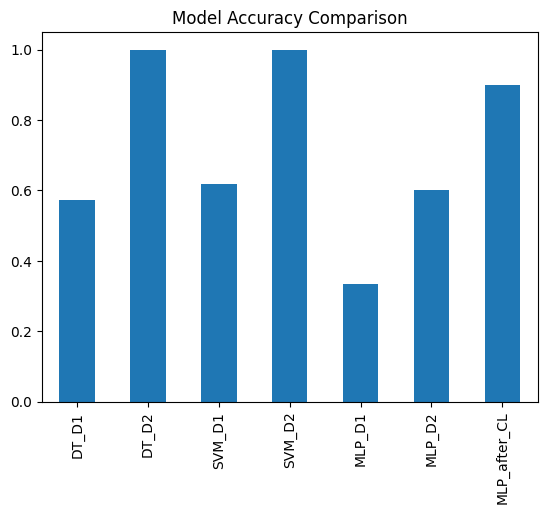

In [84]:
import matplotlib.pyplot as plt

df_results["accuracy"].plot(kind="bar")
plt.title("Model Accuracy Comparison")
plt.show()